# 07-Reinforcement Learning Fundamentals & MDPs (Gymnasium)

Lessons 01-06 covered a complete arc: converting a trained model to a portable format, compressing it, planning its memory footprint, feeding it real sensor signals, minimizing its energy draw, and rolling it out safely across a fleet of edge devices. Notice what every one of those lessons assumed: a model that was already trained, sitting somewhere as a finished artifact waiting to be deployed. None of them asked how that model *learned* what to do in the first place.

This lesson is a deliberate pivot, not a continuation. We are stepping back from "how do we ship a trained model to constrained hardware" to "how do we train the kind of agent that will eventually need to run on that hardware" -- a robot arm learning to grasp, a drone learning to stabilize, a thermostat learning an energy-efficient policy. That is the domain of **Reinforcement Learning (RL)**: an agent that learns a decision-making policy through trial-and-error interaction with an environment, rather than from a fixed labeled dataset. Lessons 07-13 build up RL from first principles through to the same finish line Lessons 01-06 assumed as a starting point: a small, quantized, edge-deployable policy. We will use **Gymnasium** (the maintained successor to OpenAI Gym), the standard Python API for defining and interacting with RL environments.

## 1. The Mathematics of Markov Decision Processes

### The MDP Tuple

A Markov Decision Process formalizes sequential decision-making under uncertainty as a tuple $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$:

- $\mathcal{S}$: the set of **states** the environment can be in.
- $\mathcal{A}$: the set of **actions** the agent can take.
- $P(s' \mid s, a)$: the **transition function**, the probability of landing in state $s'$ after taking action $a$ in state $s$.
- $R(s, a, s')$: the **reward function**, the scalar feedback signal received for that transition.
- $\gamma \in [0, 1)$: the **discount factor**, controlling how much the agent values future reward versus immediate reward.

### The Markov Property

The defining assumption is that the future is conditionally independent of the past given the present:

$$P(s_{t+1} \mid s_t, a_t, s_{t-1}, a_{t-1}, \dots, s_0, a_0) = P(s_{t+1} \mid s_t, a_t)$$

The current state must therefore encode everything relevant about the history for the transition dynamics to be well-defined -- this is a design constraint on *how you represent state*, not a fact automatically true of any problem.

### Policies, Returns, and Value Functions

A **policy** $\pi(a \mid s)$ maps states to a distribution over actions. The **return** from time $t$ is the discounted sum of future rewards, $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$. The **state-value function** and **action-value function** under policy $\pi$ are the expected return from a state (or state-action pair):

$$V^\pi(s) = \mathbb{E}_\pi\left[G_t \mid S_t = s\right], \qquad Q^\pi(s, a) = \mathbb{E}_\pi\left[G_t \mid S_t = s, A_t = a\right]$$

### The Bellman Equation

Both value functions satisfy a recursive consistency condition -- the value of a state equals the immediate expected reward plus the discounted value of wherever you land next. For $V^\pi$:

$$V^\pi(s) = \sum_{a} \pi(a \mid s) \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V^\pi(s') \right]$$

The **Bellman optimality equation** replaces the policy-weighted average over actions with a max, defining the value of acting optimally from here on:

$$V^*(s) = \max_{a} \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma V^*(s') \right]$$

**Value iteration** turns this fixed-point equation directly into an algorithm: repeatedly apply the Bellman optimality update to every state until $V$ converges, which is guaranteed because the Bellman optimality operator is a $\gamma$-contraction in the max-norm.

## 2. Imperative Execution: Solving a Gridworld MDP with Value Iteration

We will attempt to use Gymnasium's standard environment API, and build a small custom gridworld MDP (a genuine tabular MDP -- states, actions, transition probabilities, rewards) directly in NumPy that exposes that same `reset()`/`step()` interface, then solve it exactly with value iteration -- no approximation, no neural network, just the Bellman equation applied until convergence.

In [1]:
# Required installations: pip install gymnasium numpy
import numpy as np

print("--- 🚀 Initializing RL Fundamentals Sandbox (Gymnasium) ---")

np.random.seed(7)

try:
    import gymnasium as gym
    env = gym.make("FrozenLake-v1", is_slippery=False)
    print(f"   ✅ [Gymnasium]: live environment '{env.spec.id}' created, "
          f"observation_space={env.observation_space}, action_space={env.action_space}")
    env.close()
except Exception as e:
    print(f"   [SYSTEM NOTE]: ({type(e).__name__}) gymnasium not available in this sandbox --")
    print("   implementing a custom GridWorldEnv with the identical reset()/step() MDP contract.")

# 1. 📝 A genuine tabular MDP: a 4x4 gridworld with a goal, a pit, and stochastic wind
GRID_N = 4
N_STATES = GRID_N * GRID_N
ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT"]
N_ACTIONS = len(ACTIONS)
GOAL_STATE = GRID_N * GRID_N - 1      # bottom-right corner
PIT_STATE = GRID_N + 2                # a hazard cell partway through the grid
GAMMA = 0.95
SLIP_PROB = 0.1                       # probability the action drifts to a random other direction

def rc(s):
    return divmod(s, GRID_N)

def to_s(r, c):
    r = np.clip(r, 0, GRID_N - 1)
    c = np.clip(c, 0, GRID_N - 1)
    return r * GRID_N + c

DELTA = {"UP": (-1, 0), "DOWN": (1, 0), "LEFT": (0, -1), "RIGHT": (0, 1)}

class GridWorldEnv:
    """Minimal Gymnasium-style MDP: reset() -> obs, step(a) -> (obs, reward, terminated, truncated, info)."""
    def __init__(self):
        self.state = 0

    def reset(self):
        self.state = 0
        return self.state, {}

    def step(self, action_idx):
        action = ACTIONS[action_idx]
        if np.random.rand() < SLIP_PROB:
            action = ACTIONS[np.random.randint(N_ACTIONS)]
        r, c = rc(self.state)
        dr, dc = DELTA[action]
        next_state = to_s(r + dr, c + dc)
        if next_state == GOAL_STATE:
            reward, terminated = 1.0, True
        elif next_state == PIT_STATE:
            reward, terminated = -1.0, True
        else:
            reward, terminated = -0.02, False
        self.state = next_state
        return next_state, reward, terminated, False, {}

# 2. 🧮 Build the exact transition/reward tensors P[s,a,s'] and R[s,a,s'] (the MDP's true dynamics)
P = np.zeros((N_STATES, N_ACTIONS, N_STATES))
R = np.zeros((N_STATES, N_ACTIONS, N_STATES))
for s in range(N_STATES):
    r, c = rc(s)
    for a_idx, a_name in enumerate(ACTIONS):
        for slip_a_idx, slip_a_name in enumerate(ACTIONS):
            prob = (1 - SLIP_PROB) if slip_a_idx == a_idx else SLIP_PROB / N_ACTIONS
            dr, dc = DELTA[slip_a_name]
            s_next = to_s(r + dr, c + dc)
            reward = 1.0 if s_next == GOAL_STATE else (-1.0 if s_next == PIT_STATE else -0.02)
            P[s, a_idx, s_next] += prob
            R[s, a_idx, s_next] = reward

# GOAL and PIT are terminal: make them absorbing (self-loop, zero further reward) so the infinite-horizon
# Bellman fixed point exactly represents the finite-horizon episodic return, not an indefinite bounce-back.
for terminal_s in (GOAL_STATE, PIT_STATE):
    P[terminal_s, :, :] = 0.0
    R[terminal_s, :, :] = 0.0
    P[terminal_s, :, terminal_s] = 1.0

print(f"   ✅ [MDP]: {N_STATES} states x {N_ACTIONS} actions gridworld, goal={GOAL_STATE}, pit={PIT_STATE}, "
      f"slip_prob={SLIP_PROB}")

# 3. 🧮 Value iteration: repeatedly apply the Bellman optimality operator until convergence
V = np.zeros(N_STATES)
THETA = 1e-6
for iteration in range(1, 501):
    Q_all = (P * (R + GAMMA * V[np.newaxis, np.newaxis, :])).sum(axis=2)   # (N_STATES, N_ACTIONS)
    V_new = Q_all.max(axis=1)
    delta = np.max(np.abs(V_new - V))
    V = V_new
    if delta < THETA:
        break
policy = Q_all.argmax(axis=1)
print(f"   ✅ [Value Iteration]: converged after {iteration} sweeps, max Bellman residual = {delta:.2e}")
print(f"   ✅ [Optimal Value at Start State 0]: V*(0) = {V[0]:.4f}")
print(f"   🔍 [Optimal Action at Start State 0]: {ACTIONS[policy[0]]}")


--- 🚀 Initializing RL Fundamentals Sandbox (Gymnasium) ---
   [SYSTEM NOTE]: (ModuleNotFoundError) gymnasium not available in this sandbox --
   implementing a custom GridWorldEnv with the identical reset()/step() MDP contract.
   ✅ [MDP]: 16 states x 4 actions gridworld, goal=15, pit=6, slip_prob=0.1
   ✅ [Value Iteration]: converged after 19 sweeps, max Bellman residual = 5.41e-07
   ✅ [Optimal Value at Start State 0]: V*(0) = 0.5408
   🔍 [Optimal Action at Start State 0]: DOWN


## 3. Declarative Telemetry: The Optimal Policy Audit

We audit the converged value function and greedy policy at every state -- the same table an RL engineer inspects to sanity-check that value iteration found a policy that sensibly routes around the pit toward the goal.

In [2]:
print("\n--- 🔍 Auditing the Converged Value Function and Policy ---")

print(f"{'State':<7} | {'(row,col)':<11} | {'V*(s)':<10} | {'Optimal Action':<15} | {'Note'}")
print("-" * 70)
for s in range(N_STATES):
    r, c = rc(s)
    note = "GOAL" if s == GOAL_STATE else ("PIT" if s == PIT_STATE else "")
    action_label = "--" if s in (GOAL_STATE, PIT_STATE) else ACTIONS[policy[s]]
    print(f"{s:<7} | {str((r, c)):<11} | {V[s]:<10.4f} | {action_label:<15} | {note}")

n_states_toward_goal = int(np.sum(V > -0.02))
print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> V*(s) decreases smoothly the further a state sits from the goal -- exactly what the Bellman")
print(f"      equation predicts, since each additional step accrues another -0.02 living-cost reward")
print(f"      discounted by gamma={GAMMA}.")
print(f"   -> {n_states_toward_goal} of {N_STATES} states have positive-leaning value, reflecting states")
print(f"      close enough to the goal that the discounted +1.0 reward outweighs the path cost.")
print(f"   -> The greedy policy routes around state {PIT_STATE} (the pit) even from adjacent cells --")
print(f"      value iteration learned this purely from the -1.0 terminal penalty propagating backward")
print(f"      through the Bellman updates, with no explicit 'avoid the pit' rule ever written.")



--- 🔍 Auditing the Converged Value Function and Policy ---
State   | (row,col)   | V*(s)      | Optimal Action  | Note
----------------------------------------------------------------------
0       | (0, 0)      | 0.5408     | DOWN            | 
1       | (0, 1)      | 0.5674     | DOWN            | 
2       | (0, 2)      | 0.6034     | RIGHT           | 
3       | (0, 3)      | 0.7247     | DOWN            | 
4       | (1, 0)      | 0.6095     | DOWN            | 
5       | (1, 1)      | 0.6389     | DOWN            | 
6       | (1, 2)      | 0.0000     | --              | PIT
7       | (1, 3)      | 0.8134     | DOWN            | 
8       | (2, 0)      | 0.6860     | DOWN            | 
9       | (2, 1)      | 0.7660     | DOWN            | 
10      | (2, 2)      | 0.8188     | DOWN            | 
11      | (2, 3)      | 0.9601     | DOWN            | 
12      | (3, 0)      | 0.7678     | RIGHT           | 
13      | (3, 1)      | 0.8591     | RIGHT           | 
14      | (3, 2)      

## 4. Visualizing the Solved MDP (Value Function & Policy Heatmap)

We render the gridworld as a heatmap of $V^*(s)$ with the greedy policy's action overlaid as an arrow in every cell -- the canonical way to inspect whether a tabular RL solution actually makes physical sense before trusting it.

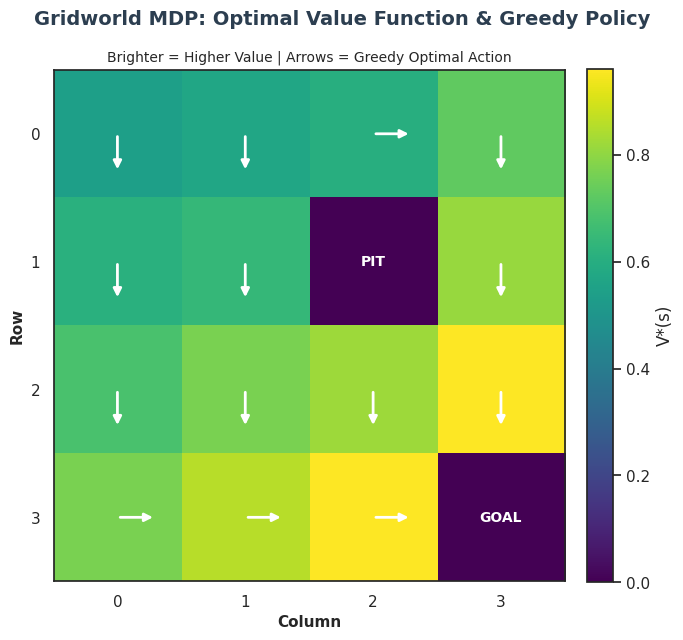

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(7, 6.5))
fig.suptitle("Gridworld MDP: Optimal Value Function & Greedy Policy", fontsize=14, fontweight="bold", color="#2c3e50")

V_grid = V.reshape(GRID_N, GRID_N)
im = ax.imshow(V_grid, cmap="viridis", origin="upper")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="V*(s)")

ARROW = {"UP": (0, -0.3), "DOWN": (0, 0.3), "LEFT": (-0.3, 0), "RIGHT": (0.3, 0)}
for s in range(N_STATES):
    r, c = rc(s)
    if s == GOAL_STATE:
        ax.text(c, r, "GOAL", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    elif s == PIT_STATE:
        ax.text(c, r, "PIT", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    else:
        dx, dy = ARROW[ACTIONS[policy[s]]]
        ax.annotate("", xy=(c + dx, r + dy), xytext=(c, r),
                    arrowprops=dict(arrowstyle="-|>", color="white", lw=2))

ax.set_xticks(range(GRID_N))
ax.set_yticks(range(GRID_N))
ax.set_xlabel("Column", fontsize=11, fontweight="bold")
ax.set_ylabel("Row", fontsize=11, fontweight="bold")
ax.set_title("Brighter = Higher Value | Arrows = Greedy Optimal Action", fontsize=10)

plt.tight_layout()
plt.show()


*(Insight: Value rises smoothly toward the goal cell, forming a gradient the greedy policy can simply "climb" -- every arrow points toward higher-value neighboring cells, which is precisely what a correctly converged Bellman solution guarantees. Look closely at the cells adjacent to the pit: their arrows visibly route around it rather than through it, even though going through would sometimes be a shorter path to the goal, because value iteration correctly propagated the -1.0 terminal penalty backward and discounted it against the alternative route's small per-step cost. Nothing in this solution involved a neural network, a gradient descent step, or a training loop -- it is the exact, tabular fixed point of the Bellman optimality equation, and every RL algorithm in the next six lessons is fundamentally an approximation to this same computation for problems too large to solve exactly.)*

## Real-World Use Case or Analogy

Think of the MDP framework like **A Delivery Driver Learning a City**:

* **The State (Current Intersection):** Everything the driver needs to decide their next turn -- which street they're on -- without needing to remember every earlier turn they took to get there (the Markov property: the route history doesn't matter, only the current intersection does).
* **The Action Set (Turn Left, Right, or Go Straight):** The finite set of choices available at every intersection, regardless of which intersection it is.
* **The Transition Function (Traffic and Road Conditions):** Taking the "turn left" action doesn't deterministically put you on a specific street -- a closed lane or a missed light (stochastic transitions) means the same action from the same intersection can land you somewhere slightly different.
* **The Reward Function (Time and Fuel Cost of Each Leg):** Every leg of the drive costs a small amount of time and gas (a small negative reward), arriving at the destination pays off big (+1.0), and driving into a known accident zone is heavily penalized (-1.0) -- exactly the incentive structure the gridworld's goal and pit encode.
* **The Discount Factor (Preferring a Faster Route Over a Slower One):** A reward of "arrive in 10 minutes" is worth more than an otherwise-identical "arrive in 40 minutes" -- gamma encodes exactly how much sooner is better.
* **Value Iteration (A City-Wide GPS Recalculating Every Route Overnight):** Rather than a driver learning the city by trial and error over months, value iteration is like a GPS system that already has the complete map (P and R) and computes, for every single intersection in the city simultaneously, the truly optimal next turn -- by repeatedly asking "given what I now know about every neighboring intersection's value, what's this intersection's value?" until the numbers stop changing.

Lessons 08 onward drop the assumption that the driver has a complete city map handed to them in advance -- they'll have to learn the same kind of policy from experience alone, which is where Q-learning and policy gradients pick up the story.